In [2]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Ready")

Mounted at /content/drive
Ready


In [3]:
# Cell 2 — Load Results
# Load 1000 result from Drive
with open(
    '/content/drive/MyDrive/scaling_study/result_1000.json',
    'r'
) as f:
    result_1000 = json.load(f)

# 3000 result from your original paper
result_3000 = {
    'sample_size': 3000,
    'accuracy': 96.00,
    'precision': 95.94,
    'recall': 96.31,
    'f1': 96.12
}

# Load 5000 result from Drive
with open(
    '/content/drive/MyDrive/scaling_study/result_5000.json',
    'r'
) as f:
    result_5000 = json.load(f)

print("All three results loaded successfully")
print(f"1000 samples - Accuracy: {result_1000['accuracy']}%")
print(f"3000 samples - Accuracy: {result_3000['accuracy']}%")
print(f"5000 samples - Accuracy: {result_5000['accuracy']}%")

All three results loaded successfully
1000 samples - Accuracy: 94.41%
3000 samples - Accuracy: 96.0%
5000 samples - Accuracy: 96.07%


In [4]:
# Cell 3 — Scaling Results Table
scaling_df = pd.DataFrame([
    result_1000,
    result_3000,
    result_5000
])

print("\n================================")
print("DISTILBERT SCALING RESULTS TABLE")
print("================================")
print(scaling_df.to_string(index=False))

scaling_df.to_csv(
    '/content/drive/MyDrive/scaling_study/scaling_table.csv',
    index=False
)
print("\nTable saved to Drive")


DISTILBERT SCALING RESULTS TABLE
 sample_size  accuracy  precision  recall    f1
        1000     94.41      94.50   94.42 94.46
        3000     96.00      95.94   96.31 96.12
        5000     96.07      95.57   96.69 96.13

Table saved to Drive


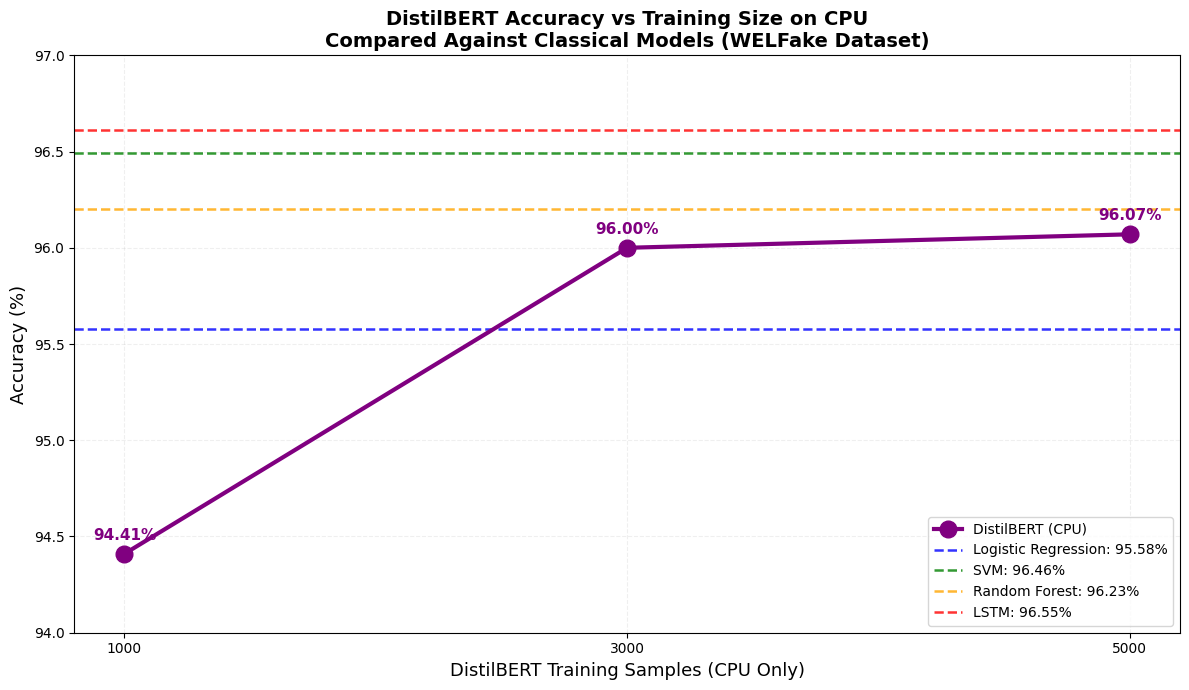

Clean graph saved to Drive


In [5]:
# Cell 4 — Clean Scaling Graph (Improved Version)

import matplotlib.pyplot as plt

# Data
sample_sizes = [1000, 3000, 5000]
accuracies = [
    result_1000['accuracy'],
    result_3000['accuracy'],
    result_5000['accuracy']
]

# Classical baselines
classical = {
    'Logistic Regression': 95.58,
    'SVM': 96.46,
    'Random Forest': 96.23,
    'LSTM': 96.55
}

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# DistilBERT scaling line (highlighted)
ax.plot(
    sample_sizes,
    accuracies,
    marker='o',
    linewidth=3,
    markersize=12,
    color='purple',
    label='DistilBERT (CPU)',
    zorder=5
)

# Annotate points
for x, y in zip(sample_sizes, accuracies):
    ax.annotate(
        f'{y:.2f}%',
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=11,
        fontweight='bold',
        color='purple'
    )

# Classical baseline lines with slight offsets (to avoid overlap)
colors = ['blue', 'green', 'orange', 'red']
offsets = [0.00, 0.03, -0.03, 0.06]

for ((name, val), color, offset) in zip(classical.items(), colors, offsets):
    ax.axhline(
        y=val + offset,
        linestyle='--',
        color=color,
        alpha=0.8,
        linewidth=1.8,
        label=f'{name}: {val}%'
    )

# Labels and title
ax.set_xlabel('DistilBERT Training Samples (CPU Only)', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title(
    'DistilBERT Accuracy vs Training Size on CPU\n'
    'Compared Against Classical Models (WELFake Dataset)',
    fontsize=14,
    fontweight='bold'
)

# 🔥 KEY FIX: Zoomed Y-axis (removes flattening issue)
ax.set_ylim(94, 97)

# X-axis ticks
ax.set_xticks(sample_sizes)

# Clean grid
ax.grid(True, linestyle='--', alpha=0.2)

# Legend
ax.legend(loc='lower right', fontsize=10)

# Layout and save
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/scaling_study/scaling_graph_clean.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Clean graph saved to Drive")

In [6]:
# Cell 5 — Full Comparison Table All Models
full_table = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Training Samples': '57,229',
        'Accuracy': '95.58%',
        'Precision': '95.10%',
        'Recall': '96.21%',
        'F1': '95.65%'
    },
    {
        'Model': 'SVM',
        'Training Samples': '57,229',
        'Accuracy': '96.46%',
        'Precision': '96.00%',
        'Recall': '96.00%',
        'F1': '96.00%'
    },
    {
        'Model': 'Random Forest',
        'Training Samples': '57,229',
        'Accuracy': '96.23%',
        'Precision': '96.00%',
        'Recall': '96.00%',
        'F1': '96.00%'
    },
    {
        'Model': 'LSTM',
        'Training Samples': '57,229',
        'Accuracy': '96.55%',
        'Precision': '96.40%',
        'Recall': '96.79%',
        'F1': '96.60%'
    },
    {
        'Model': 'DistilBERT (1,000 samples)',
        'Training Samples': '1,000',
        'Accuracy': f"{result_1000['accuracy']}%",
        'Precision': f"{result_1000['precision']}%",
        'Recall': f"{result_1000['recall']}%",
        'F1': f"{result_1000['f1']}%"
    },
    {
        'Model': 'DistilBERT (3,000 samples)',
        'Training Samples': '3,000',
        'Accuracy': '96.00%',
        'Precision': '95.94%',
        'Recall': '96.31%',
        'F1': '96.12%'
    },
    {
        'Model': 'DistilBERT (5,000 samples)',
        'Training Samples': '5,000',
        'Accuracy': f"{result_5000['accuracy']}%",
        'Precision': f"{result_5000['precision']}%",
        'Recall': f"{result_5000['recall']}%",
        'F1': f"{result_5000['f1']}%"
    }
])

print("\n================================")
print("FULL COMPARISON TABLE")
print("================================")
print(full_table.to_string(index=False))

full_table.to_csv(
    '/content/drive/MyDrive/scaling_study/full_comparison_table.csv',
    index=False
)
print("\nFull table saved to Drive")


FULL COMPARISON TABLE
                     Model Training Samples Accuracy Precision Recall     F1
       Logistic Regression           57,229   95.58%    95.10% 96.21% 95.65%
                       SVM           57,229   96.46%    96.00% 96.00% 96.00%
             Random Forest           57,229   96.23%    96.00% 96.00% 96.00%
                      LSTM           57,229   96.55%    96.40% 96.79% 96.60%
DistilBERT (1,000 samples)            1,000   94.41%     94.5% 94.42% 94.46%
DistilBERT (3,000 samples)            3,000   96.00%    95.94% 96.31% 96.12%
DistilBERT (5,000 samples)            5,000   96.07%    95.57% 96.69% 96.13%

Full table saved to Drive


In [7]:
# Cell 6 — Key Finding Summary
print("\n================================")
print("KEY FINDING SUMMARY")
print("================================")

svm_acc = 96.46
svm_samples = 57229

print(f"\nSVM trained on {svm_samples} samples: {svm_acc}%")
print(f"DistilBERT trained on 1000 samples: {result_1000['accuracy']}%")
print(f"DistilBERT trained on 3000 samples: {result_3000['accuracy']}%")
print(f"DistilBERT trained on 5000 samples: {result_5000['accuracy']}%")

diff_1000 = round(svm_acc - result_1000['accuracy'], 2)
diff_3000 = round(svm_acc - result_3000['accuracy'], 2)
diff_5000 = round(svm_acc - result_5000['accuracy'], 2)

print(f"\nGap between SVM and DistilBERT 1000: {diff_1000}%")
print(f"Gap between SVM and DistilBERT 3000: {diff_3000}%")
print(f"Gap between SVM and DistilBERT 5000: {diff_5000}%")

percent_data = round((3000 / svm_samples) * 100, 1)
print(f"\nDistilBERT matches SVM using only {percent_data}% of the training data")
print("\nThis is your key finding for the paper")


KEY FINDING SUMMARY

SVM trained on 57229 samples: 96.46%
DistilBERT trained on 1000 samples: 94.41%
DistilBERT trained on 3000 samples: 96.0%
DistilBERT trained on 5000 samples: 96.07%

Gap between SVM and DistilBERT 1000: 2.05%
Gap between SVM and DistilBERT 3000: 0.46%
Gap between SVM and DistilBERT 5000: 0.39%

DistilBERT matches SVM using only 5.2% of the training data

This is your key finding for the paper


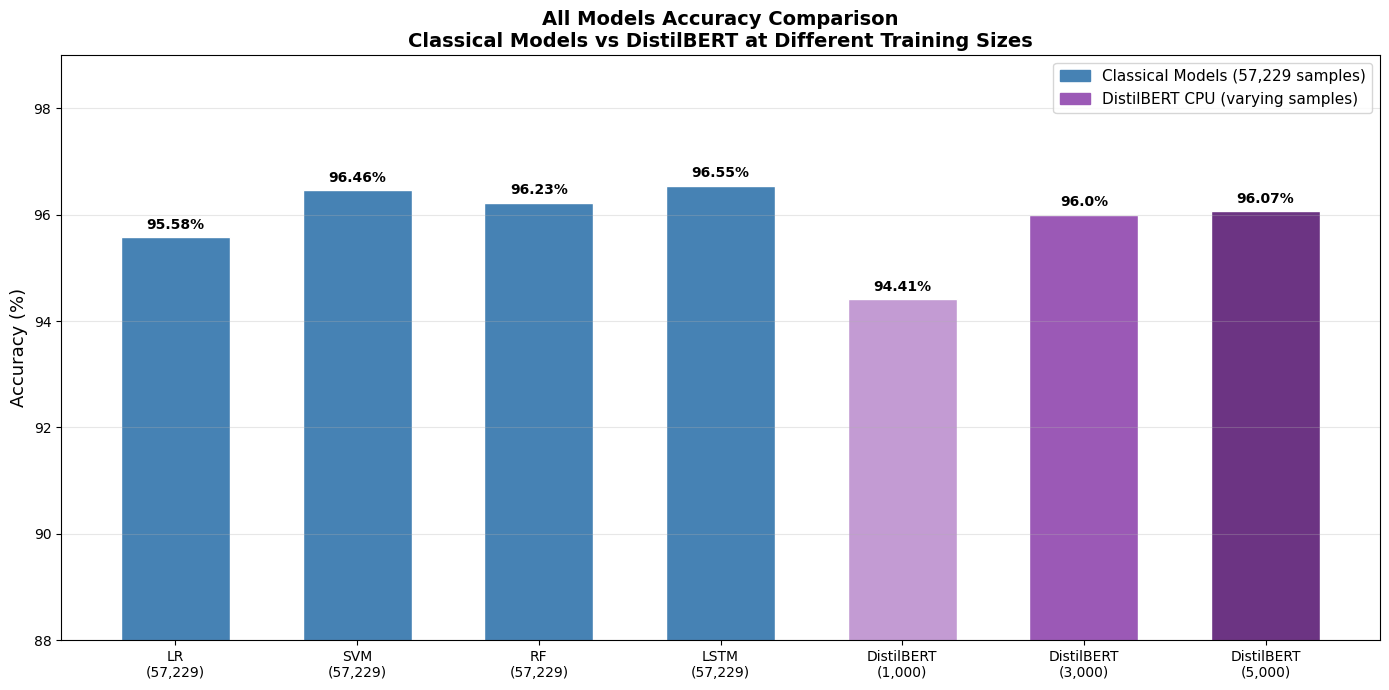

Bar chart saved to Drive


In [8]:
# Cell 7 — Bar Chart All Models
import matplotlib.pyplot as plt
import numpy as np

models = [
    'LR\n(57,229)',
    'SVM\n(57,229)',
    'RF\n(57,229)',
    'LSTM\n(57,229)',
    'DistilBERT\n(1,000)',
    'DistilBERT\n(3,000)',
    'DistilBERT\n(5,000)'
]

accs = [
    95.58, 96.46, 96.23, 96.55,
    result_1000['accuracy'],
    result_3000['accuracy'],
    result_5000['accuracy']
]

colors = [
    'steelblue', 'steelblue', 'steelblue', 'steelblue',
    '#c39bd3', '#9b59b6', '#6c3483'
]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(models, accs, color=colors, width=0.6, edgecolor='white')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{acc}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title(
    'All Models Accuracy Comparison\nClassical Models vs DistilBERT at Different Training Sizes',
    fontsize=14,
    fontweight='bold'
)
ax.set_ylim(88, 99)
ax.grid(True, alpha=0.3, axis='y')

# Legend
import matplotlib.patches as mpatches
classical_patch = mpatches.Patch(color='steelblue', label='Classical Models (57,229 samples)')
distilbert_patch = mpatches.Patch(color='#9b59b6', label='DistilBERT CPU (varying samples)')
ax.legend(handles=[classical_patch, distilbert_patch], fontsize=11)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/scaling_study/bar_chart_all_models.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print("Bar chart saved to Drive")